# Retail Customer Segmentation Analysis

Dataset: `Customers.csv`


## 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)


## 2. Upload và đọc file CSV


In [3]:
file_path = "Customers.csv"

df = pd.read_csv(file_path)
df.head()


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


## 3.

In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())
display(df.info())
display(df.describe(include="all"))


Shape: (2000, 8)

Columns:
['CustomerID', 'Gender', 'Age', 'Annual Income ($)', 'Spending Score (1-100)', 'Profession', 'Work Experience', 'Family Size']


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              2000 non-null   int64 
 1   Gender                  2000 non-null   object
 2   Age                     2000 non-null   int64 
 3   Annual Income ($)       2000 non-null   int64 
 4   Spending Score (1-100)  2000 non-null   int64 
 5   Profession              1965 non-null   object
 6   Work Experience         2000 non-null   int64 
 7   Family Size             2000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 125.1+ KB


None

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
count,2000.000000,2000,2000.000000,2000.000000,2000.000000,1965,2000.000000,2000.000000
unique,NaN,2,NaN,NaN,NaN,9,NaN,NaN
top,NaN,Female,NaN,NaN,NaN,Artist,NaN,NaN
freq,NaN,1186,NaN,NaN,NaN,612,NaN,NaN
mean,1000.500000,NaN,48.960000,110731.821500,50.962500,NaN,4.102500,3.768500
std,577.494589,NaN,28.429747,45739.536688,27.934661,NaN,3.922204,1.970749
min,1.000000,NaN,0.000000,0.000000,0.000000,NaN,0.000000,1.000000
25%,500.750000,NaN,25.000000,74572.000000,28.000000,NaN,1.000000,2.000000
50%,1000.500000,NaN,48.000000,110045.000000,50.000000,NaN,3.000000,4.000000
75%,1500.250000,NaN,73.000000,149092.750000,75.000000,NaN,7.000000,5.000000


In [5]:
# Kiểm tra missing values
missing = df.isna().sum().sort_values(ascending=False)
missing


,0
Profession,35
CustomerID,0
Age,0
Gender,0
Annual Income ($),0
Spending Score (1-100),0
Work Experience,0
Family Size,0


In [6]:
# Kiểm tra duplicate theo CustomerID
duplicate_count = df.duplicated(subset=["CustomerID"]).sum()
print("Duplicate CustomerID:", duplicate_count)


Duplicate CustomerID: 0


## 4. Làm sạch dữ liệu

In [7]:
# Đổi tên cột
df_clean = df.rename(columns={
    "Annual Income ($)": "Annual_Income",
    "Spending Score (1-100)": "Spending_Score",
    "Work Experience": "Work_Experience",
    "Family Size": "Family_Size"
})

# Loại duplicate theo CustomerID
df_clean = df_clean.drop_duplicates(subset=["CustomerID"], keep="first")

# Xử lý missing Profession
df_clean["Profession"] = df_clean["Profession"].fillna("Unknown")

df_clean.head()


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Profession,Work_Experience,Family_Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


In [8]:
# Kiểm tra outlier Annual Income bằng IQR
Q1 = df_clean["Annual_Income"].quantile(0.25)
Q3 = df_clean["Annual_Income"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[
    (df_clean["Annual_Income"] < lower_bound) |
    (df_clean["Annual_Income"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))


Q1: 74572.0
Q3: 149092.75
IQR: 74520.75
Lower bound: -37209.125
Upper bound: 260873.875
Number of outliers: 0


In [9]:
# Nếu có outlier, có thể lọc bỏ. Nếu không có thì giữ nguyên.
df_clean = df_clean[
    (df_clean["Annual_Income"] >= lower_bound) &
    (df_clean["Annual_Income"] <= upper_bound)
].copy()

print("Shape after cleaning:", df_clean.shape)


Shape after cleaning: (2000, 8)


## 5. Tạo cột mới phục vụ phân tích


In [10]:
def income_group(income):
    if income < 50000:
        return "Low"
    elif income <= 100000:
        return "Medium"
    else:
        return "High"

def spending_category(score):
    if score < 40:
        return "Low"
    elif score <= 69:
        return "Medium"
    else:
        return "High"

def customer_segment(row):
    income = row["Annual_Income"]
    score = row["Spending_Score"]

    if income > 100000 and score < 40:
        return "High Income - Low Spending"
    elif income > 100000 and score >= 70:
        return "High Income - High Spending"
    elif income < 50000 and score >= 70:
        return "Low Income - High Spending"
    elif income < 50000 and score < 40:
        return "Low Income - Low Spending"
    else:
        return "Regular / Medium Segment"

df_clean["Income_Group"] = df_clean["Annual_Income"].apply(income_group)
df_clean["Spending_Category"] = df_clean["Spending_Score"].apply(spending_category)
df_clean["Customer_Segment"] = df_clean.apply(customer_segment, axis=1)

df_clean.head()


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Profession,Work_Experience,Family_Size,Income_Group,Spending_Category,Customer_Segment
0,1,Male,19,15000,39,Healthcare,1,4,Low,Low,Low Income - Low Spending
1,2,Male,21,35000,81,Engineer,3,3,Low,High,Low Income - High Spending
2,3,Female,20,86000,6,Engineer,1,1,Medium,Low,Regular / Medium Segment
3,4,Female,23,59000,77,Lawyer,0,2,Medium,High,Regular / Medium Segment
4,5,Female,31,38000,40,Entertainment,2,6,Low,Medium,Regular / Medium Segment


## 6.

In [12]:
# Tổng quan theo Gender
gender_summary = df_clean.groupby("Gender").agg(
    Total_Customers=("CustomerID", "count"),
    Avg_Income=("Annual_Income", "mean"),
    Avg_Spending=("Spending_Score", "mean"),
    Avg_Age=("Age", "mean")
).round(2)

gender_summary


,Total_Customers,Avg_Income,Avg_Spending,Avg_Age
Gender,,,,
Female,1186,110553.72,50.97,48.82
Male,814,110991.32,50.94,49.16


In [13]:
# Spending theo Profession
profession_summary = df_clean.groupby("Profession").agg(
    Total_Customers=("CustomerID", "count"),
    Avg_Income=("Annual_Income", "mean"),
    Avg_Spending=("Spending_Score", "mean"),
    Avg_Work_Experience=("Work_Experience", "mean")
).round(2).sort_values("Avg_Spending", ascending=False)

profession_summary


,Total_Customers,Avg_Income,Avg_Spending,Avg_Work_Experience
Profession,,,,
Entertainment,234,110650.33,52.94,3.50
Artist,612,108776.58,52.68,4.22
Doctor,161,111573.22,51.90,4.30
Healthcare,339,112574.04,50.52,4.00
Executive,153,113770.13,49.90,4.25
Engineer,179,111161.24,48.97,3.96
Lawyer,142,110995.84,48.86,3.53
Marketing,85,107994.21,48.72,4.31
Homemaker,60,108758.62,46.38,6.13


In [14]:
# Spending theo Family Size
family_summary = df_clean.groupby("Family_Size").agg(
    Total_Customers=("CustomerID", "count"),
    Avg_Income=("Annual_Income", "mean"),
    Avg_Spending=("Spending_Score", "mean")
).round(2)

family_summary


,Total_Customers,Avg_Income,Avg_Spending
Family_Size,,,
1,299,108752.38,49.65
2,361,104697.35,50.36
3,311,106412.51,51.95
4,289,109476.15,52.71
5,258,114283.46,52.18
6,243,119060.24,49.94
7,234,118191.60,49.99
8,4,78607.75,49.25
9,1,30000.00,17.00


In [15]:
# Summary theo Customer Segment
segment_summary = df_clean.groupby("Customer_Segment").agg(
    Total_Customers=("CustomerID", "count"),
    Avg_Income=("Annual_Income", "mean"),
    Avg_Spending=("Spending_Score", "mean"),
    Avg_Age=("Age", "mean"),
    Avg_Family_Size=("Family_Size", "mean")
).round(2).sort_values("Total_Customers", ascending=False)

segment_summary


,Total_Customers,Avg_Income,Avg_Spending,Avg_Age,Avg_Family_Size
Customer_Segment,,,,,
Regular / Medium Segment,1168,95611.45,51.03,49.21,3.77
High Income - Low Spending,402,145313.27,21.51,50.73,3.90
High Income - High Spending,342,144004.47,85.79,47.01,3.85
Low Income - Low Spending,47,23914.89,19.87,48.87,2.74
Low Income - High Spending,41,24390.24,83.12,40.83,3.00


## 7. Trực quan hóa


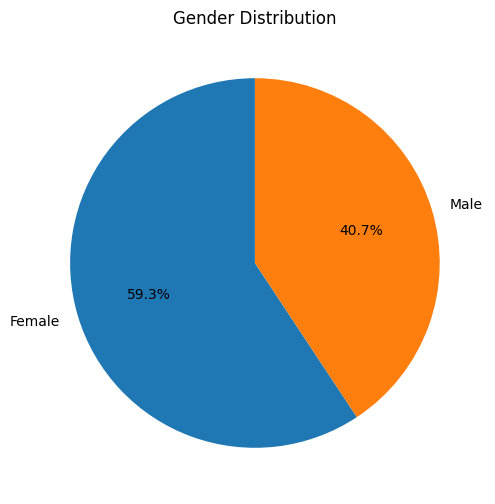

In [16]:
# 7.1 Gender distribution
gender_counts = df_clean["Gender"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender_counts.values, labels=gender_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Gender Distribution")
plt.show()


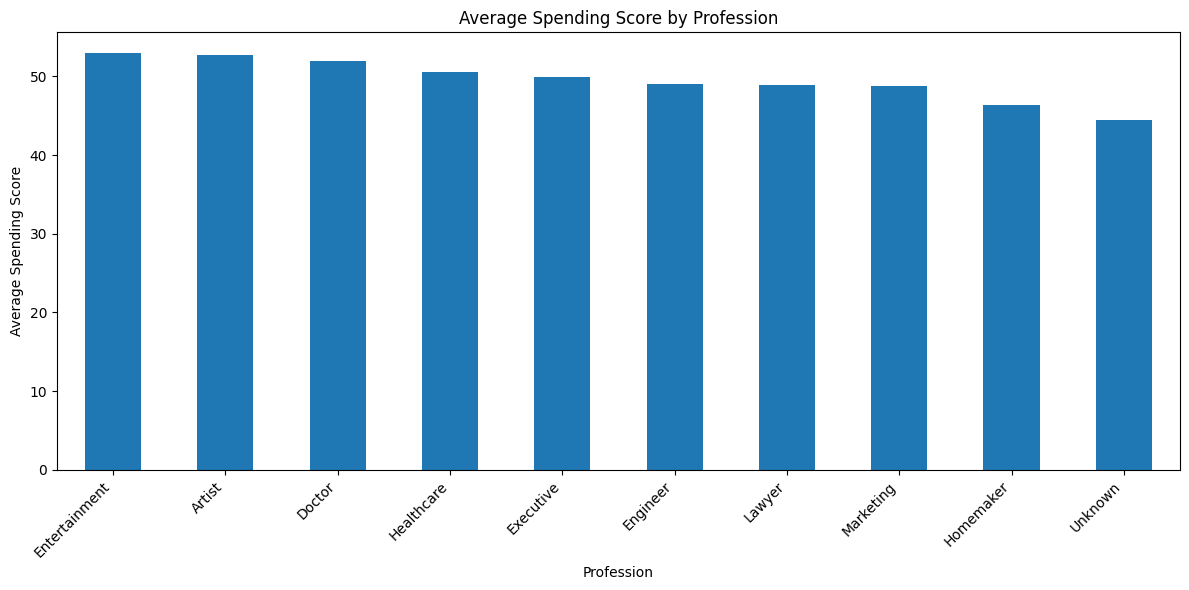

In [17]:
# 7.2 Average Spending by Profession
avg_spending_profession = df_clean.groupby("Profession")["Spending_Score"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
avg_spending_profession.plot(kind="bar")
plt.title("Average Spending Score by Profession")
plt.xlabel("Profession")
plt.ylabel("Average Spending Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


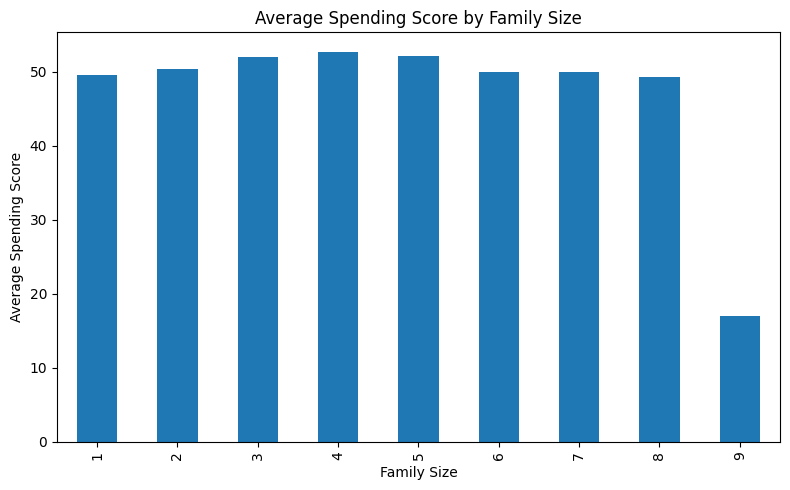

In [18]:
# 7.3 Average Spending by Family Size
avg_spending_family = df_clean.groupby("Family_Size")["Spending_Score"].mean()

plt.figure(figsize=(8, 5))
avg_spending_family.plot(kind="bar")
plt.title("Average Spending Score by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Average Spending Score")
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

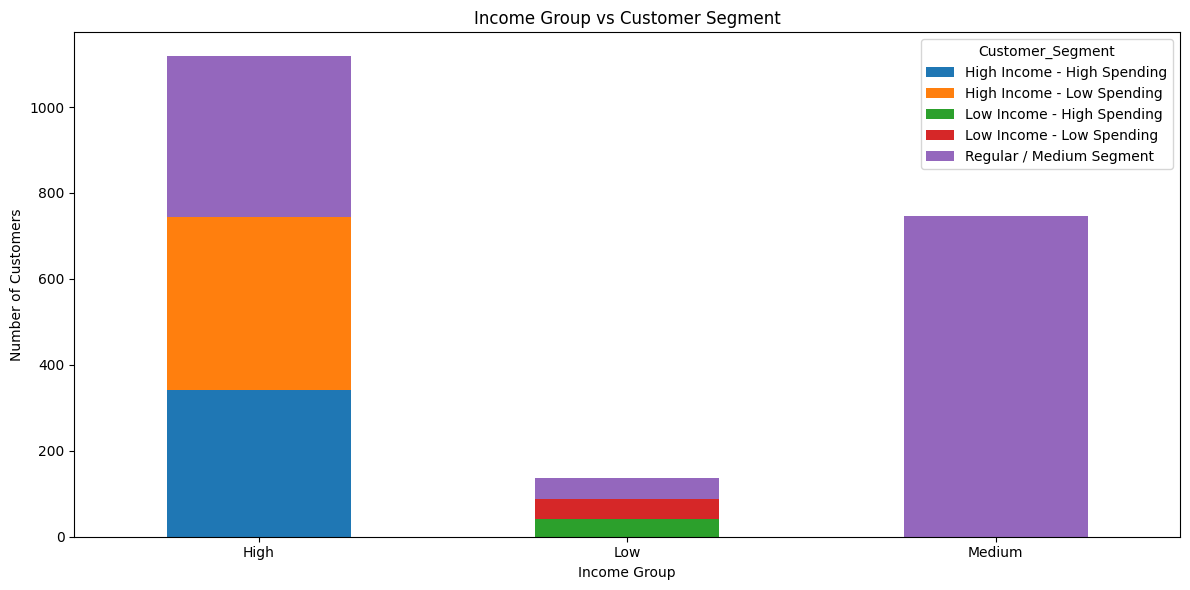

In [19]:
# 7.4 Income Group vs Customer Segment
income_segment = pd.crosstab(df_clean["Income_Group"], df_clean["Customer_Segment"])

plt.figure(figsize=(12, 6))
income_segment.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Income Group vs Customer Segment")
plt.xlabel("Income Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


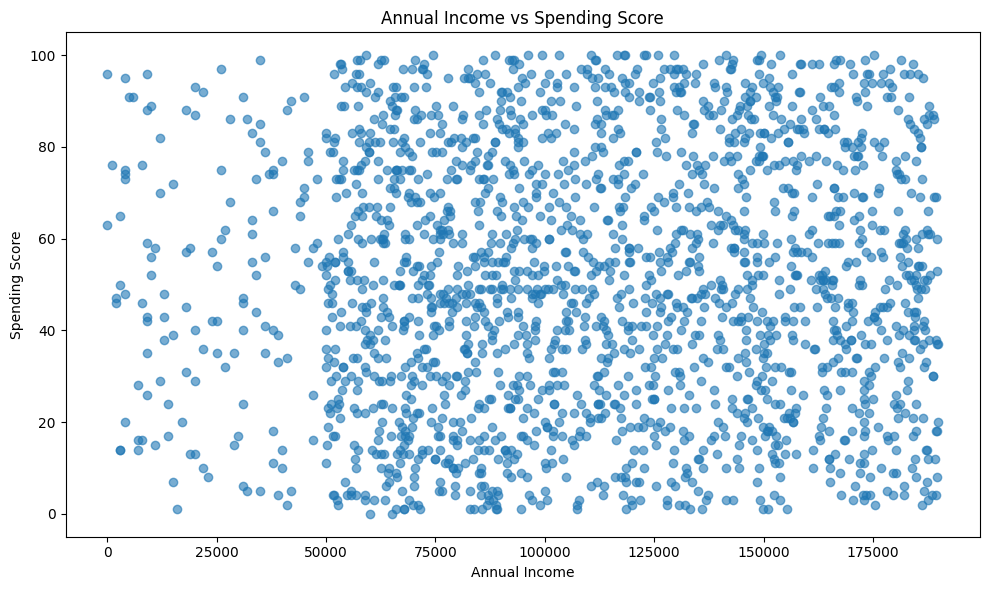

In [20]:
# 7.5 Annual Income vs Spending Score
plt.figure(figsize=(10, 6))
plt.scatter(df_clean["Annual_Income"], df_clean["Spending_Score"], alpha=0.6)
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.tight_layout()
plt.show()


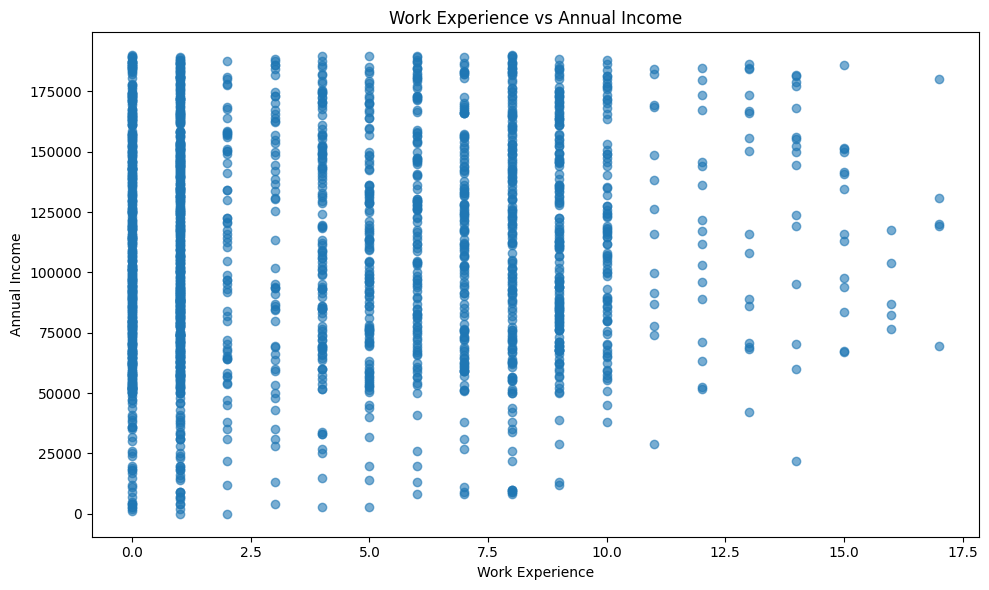

In [21]:
# 7.6 Work Experience vs Annual Income
plt.figure(figsize=(10, 6))
plt.scatter(df_clean["Work_Experience"], df_clean["Annual_Income"], alpha=0.6)
plt.title("Work Experience vs Annual Income")
plt.xlabel("Work Experience")
plt.ylabel("Annual Income")
plt.tight_layout()
plt.show()


## 8. Train mô hình

In [22]:
cluster_features = [
    "Age",
    "Annual_Income",
    "Spending_Score",
    "Work_Experience",
    "Family_Size"
]

X_cluster = df_clean[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


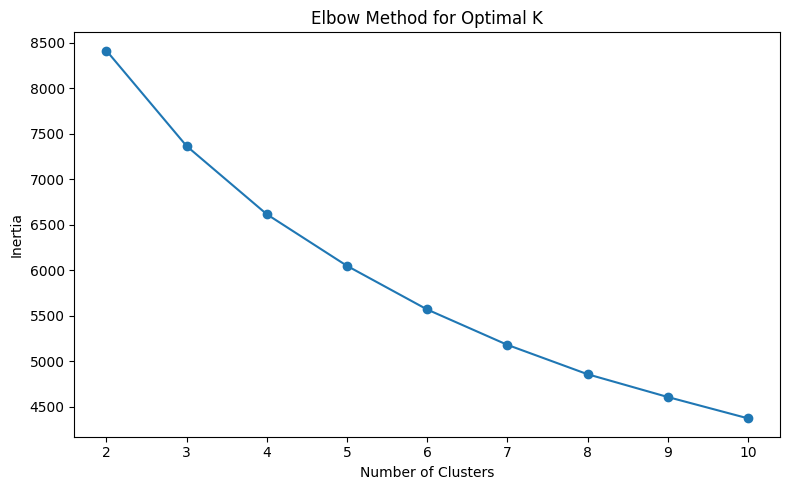

In [23]:
# Elbow Method
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()


In [24]:
# Silhouette Score
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

silhouette_df = pd.DataFrame({
    "k": list(K_range),
    "silhouette_score": silhouette_scores
})

silhouette_df


,k,silhouette_score
0,2,0.160742
1,3,0.154023
2,4,0.148137
3,5,0.156233
4,6,0.158778
5,7,0.162837
6,8,0.167694
7,9,0.167663
8,10,0.173862


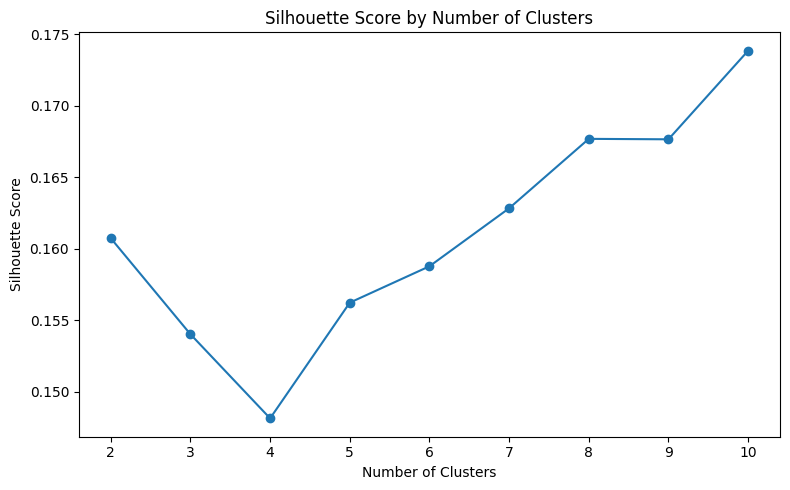

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(silhouette_df["k"], silhouette_df["silhouette_score"], marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()


In [26]:
# Chọn k tốt nhất theo silhouette score
best_k = silhouette_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"]
best_k = int(best_k)

print("Best k by silhouette score:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clean["Cluster"] = kmeans.fit_predict(X_scaled)

df_clean[["CustomerID", "Annual_Income", "Spending_Score", "Cluster"]].head()


Best k by silhouette score: 10


,CustomerID,Annual_Income,Spending_Score,Cluster
0,1,15000,39,1
1,2,35000,81,5
2,3,86000,6,1
3,4,59000,77,5
4,5,38000,40,1


In [27]:
# Phân tích từng cluster
cluster_summary = df_clean.groupby("Cluster").agg(
    Total_Customers=("CustomerID", "count"),
    Avg_Age=("Age", "mean"),
    Avg_Income=("Annual_Income", "mean"),
    Avg_Spending=("Spending_Score", "mean"),
    Avg_Work_Experience=("Work_Experience", "mean"),
    Avg_Family_Size=("Family_Size", "mean")
).round(2).sort_values("Avg_Spending", ascending=False)

cluster_summary


,Total_Customers,Avg_Age,Avg_Income,Avg_Spending,Avg_Work_Experience,Avg_Family_Size
Cluster,,,,,,
2,152,28.30,137091.62,80.64,8.83,3.70
5,238,25.93,71877.74,78.51,2.13,2.95
3,223,78.30,110466.30,78.42,1.56,3.22
0,153,72.25,114361.27,58.52,8.46,6.10
7,216,22.32,136470.07,49.04,2.86,6.15
6,201,35.92,157609.33,41.38,1.69,2.16
9,183,77.57,125746.36,38.10,8.00,2.52
8,214,74.56,120592.48,32.92,1.45,5.68
4,177,25.97,94060.01,27.89,9.06,2.87


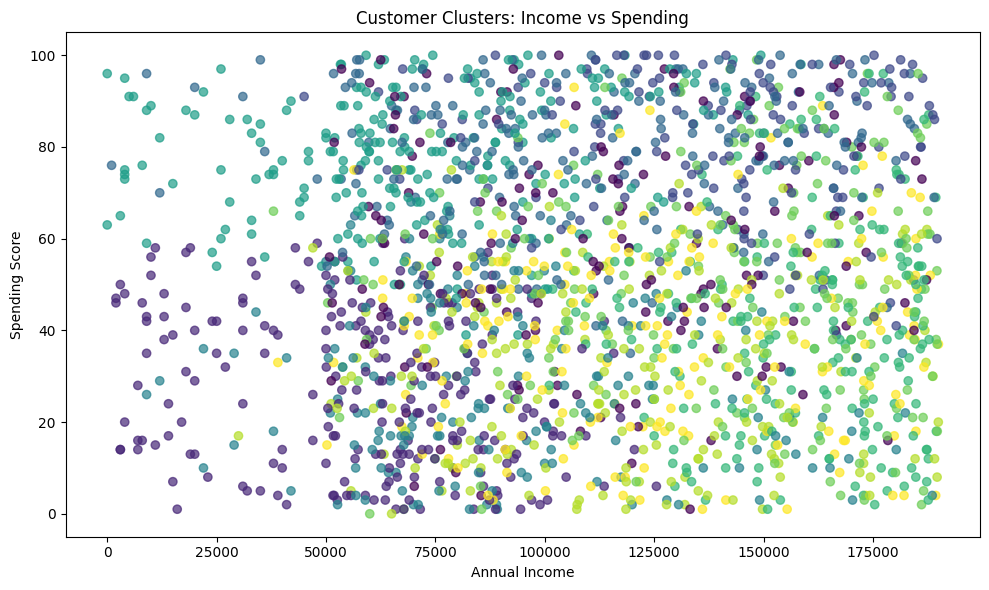

In [28]:
# Visualize clusters
plt.figure(figsize=(10, 6))
plt.scatter(
    df_clean["Annual_Income"],
    df_clean["Spending_Score"],
    c=df_clean["Cluster"],
    alpha=0.7
)
plt.title("Customer Clusters: Income vs Spending")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.tight_layout()
plt.show()


## 9. Train mô hình dự đoán khách hàng chi tiêu cao

dự đoán khách hàng có thuộc nhóm High Spending hay không.

Target:
- 1 nếu Spending_Score >= 70
- 0 nếu ngược lại




In [29]:
df_model = df_clean.copy()
df_model["Is_High_Spending"] = (df_model["Spending_Score"] >= 70).astype(int)

features = [
    "Gender",
    "Age",
    "Annual_Income",
    "Profession",
    "Work_Experience",
    "Family_Size",
    "Income_Group"
]

target = "Is_High_Spending"

X = df_model[features]
y = df_model[target]

categorical_features = ["Gender", "Profession", "Income_Group"]
numeric_features = ["Age", "Annual_Income", "Work_Experience", "Family_Size"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)


## 10. Đánh giá mô hình

In [30]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.6825

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.94      0.80       280
           1       0.38      0.09      0.15       120

    accuracy                           0.68       400
   macro avg       0.54      0.51      0.48       400
weighted avg       0.61      0.68      0.61       400


Confusion Matrix:
[[262  18]
 [109  11]]


In [31]:
# Feature importance
model = clf.named_steps["model"]
preprocessor_fitted = clf.named_steps["preprocessor"]

cat_names = preprocessor_fitted.named_transformers_["cat"].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_names)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df.head(15)


,Feature,Importance
1,Annual_Income,0.273830
0,Age,0.249356
2,Work_Experience,0.149353
3,Family_Size,0.124659
6,Profession_Artist,0.022683
11,Profession_Healthcare,0.017722
9,Profession_Entertainment,0.016250
4,Gender_Female,0.015779
5,Gender_Male,0.015426
10,Profession_Executive,0.015384


<Figure size 1000x600 with 0 Axes>

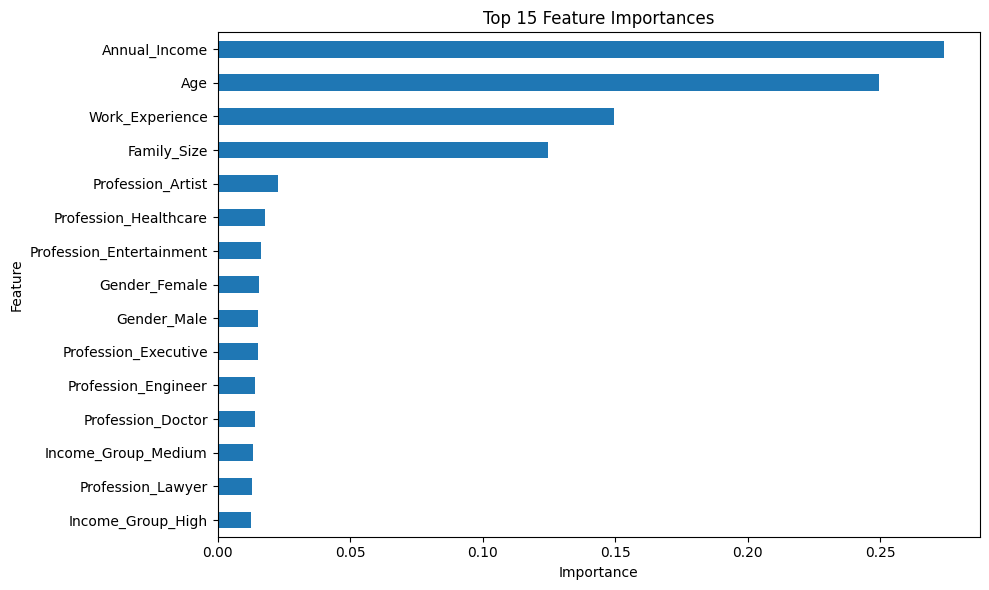

In [32]:
plt.figure(figsize=(10, 6))
importance_df.head(15).sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False,
    figsize=(10, 6)
)
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 11. Insights


In [33]:
top_profession = profession_summary.index[0]
top_profession_spending = profession_summary.iloc[0]["Avg_Spending"]

top_segment = segment_summary.index[0]
top_segment_count = segment_summary.iloc[0]["Total_Customers"]

highest_spending_segment = segment_summary.sort_values("Avg_Spending", ascending=False).index[0]
highest_spending_score = segment_summary.sort_values("Avg_Spending", ascending=False).iloc[0]["Avg_Spending"]

top_family = family_summary.sort_values("Avg_Spending", ascending=False).index[0]
top_family_score = family_summary.sort_values("Avg_Spending", ascending=False).iloc[0]["Avg_Spending"]

print("INSIGHTS")
print("1.", f"Profession có Spending Score trung bình cao nhất là {top_profession}, với điểm trung bình {top_profession_spending}.")
print("2.", f"Segment có số lượng khách hàng lớn nhất là {top_segment}, với {top_segment_count} khách hàng.")
print("3.", f"Segment có mức chi tiêu trung bình cao nhất là {highest_spending_segment}, với Spending Score trung bình {highest_spending_score}.")
print("4.", f"Family Size có mức chi tiêu trung bình cao nhất là {top_family}, với Spending Score trung bình {top_family_score}.")
print("5.", "Nhóm High Income - Low Spending nên được remarketing vì có khả năng chi trả cao nhưng chưa chi tiêu mạnh.")


INSIGHTS
1. Profession có Spending Score trung bình cao nhất là Entertainment, với điểm trung bình 52.94.
2. Segment có số lượng khách hàng lớn nhất là Regular / Medium Segment, với 1168.0 khách hàng.
3. Segment có mức chi tiêu trung bình cao nhất là High Income - High Spending, với Spending Score trung bình 85.79.
4. Family Size có mức chi tiêu trung bình cao nhất là 4, với Spending Score trung bình 52.71.
5. Nhóm High Income - Low Spending nên được remarketing vì có khả năng chi trả cao nhưng chưa chi tiêu mạnh.


## 12. Đề xuất chiến lược

### 1. Nhóm High Income - High Spending
Đây là nhóm khách hàng giá trị nhất. Nên triển khai:
- VIP loyalty program
- Ưu đãi độc quyền
- Early access sản phẩm mới

### 2. Nhóm High Income - Low Spending
Đây là nhóm có tiền nhưng chưa mua nhiều. Nên triển khai:
- Personalized voucher
- Remarketing campaign
- Gợi ý sản phẩm theo nghề nghiệp và độ tuổi

### 3. Nhóm Family Size lớn
Khách hàng gia đình nên được nhắm bằng:
- Combo gia đình
- Ưu đãi mua nhiều
- Membership theo hộ gia đình

### 4. Profession chi tiêu cao
Các nghề có Spending Score cao nên được target bằng:
- Quảng cáo riêng theo ngành nghề
- Campaign theo lifestyle
- Ưu đãi theo nhu cầu nghề nghiệp
